##### Check if if jupyter use the correct path

In [1]:
import sys
print(sys.executable)


C:\Users\brahi\Desktop\churn-mlops\venv\Scripts\python.exe


In [2]:
import pandas as pd
import sklearn

In [5]:
df=pd.read_csv("../data/raw/churn.csv")  

In [68]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.shape

(7043, 21)

In [7]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


##### TotalCharge contains float values but the data type is object we have to convert it to float

In [14]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors='coerce')

##### Check if the data type is converted correctelly

In [15]:
df["TotalCharges"].dtype

dtype('float64')

In [35]:
missing_rows=df[df["TotalCharges"].isna()]

In [34]:
missing_rows[["TotalCharges","tenure","Churn"]]

,TotalCharges,tenure,Churn
488,NaN,0,No
753,NaN,0,No
936,NaN,0,No
1082,NaN,0,No
1340,NaN,0,No
3331,NaN,0,No
3826,NaN,0,No
4380,NaN,0,No
5218,NaN,0,No
6670,NaN,0,No


##### We have 11 missing values 

In [36]:
len(missing_rows)/len(df)*100

0.1561834445548772

##### The percentage of missing values is approximately 0.16%.
##### Since this represents a very small portion of the dataset,
##### we will drop these rows.

In [37]:
df = df.dropna(subset=["TotalCharges"])
print(df.shape)

(7032, 21)


##### Check duplicated customer

In [39]:
df["customerID"].duplicated().sum()

np.int64(0)

#####  Understand the target variable

In [41]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [42]:
df["Churn"].value_counts(normalize=True)*100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

##### The target variable is moderately imbalanced, with approximately
##### 73.4% non-churn customers and 26.6% churn customers.

In [45]:
pip install  seaborn 

  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: C:\Users\brahi\Desktop\churn-mlops\venv\Scripts\python.exe -m pip install --upgrade pip


<Axes: xlabel='Churn', ylabel='count'>

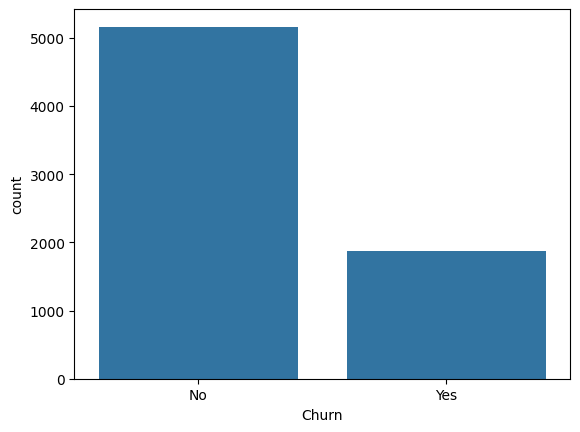

In [46]:
import seaborn as sns
sns.countplot(x="Churn", data=df)

#####   Numerical featues anlysis

In [47]:
categorical_features = [
    col for col in df.columns
    if df[col].dtype == "object"
]

In [49]:
numerical_features = [
    col for col in df.columns
    if df[col].dtype != "object"
]

In [50]:
numerical_features

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

In [51]:
df[numerical_features].describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


##### Distributions

array([[<Axes: title={'center': 'SeniorCitizen'}>,
        <Axes: title={'center': 'tenure'}>],
       [<Axes: title={'center': 'MonthlyCharges'}>,
        <Axes: title={'center': 'TotalCharges'}>]], dtype=object)

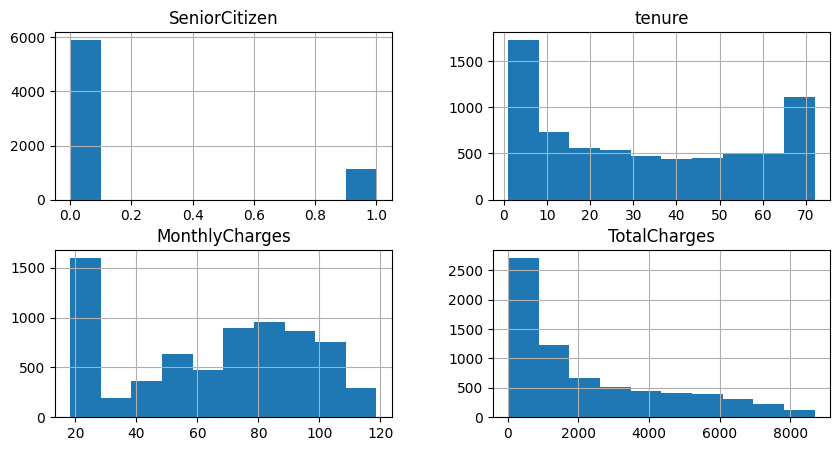

In [53]:
df[numerical_features].hist(figsize=(10,5))

##### Check for outliers

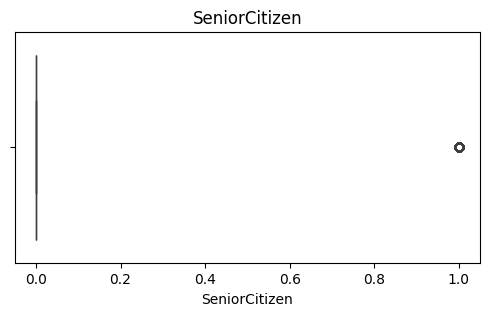

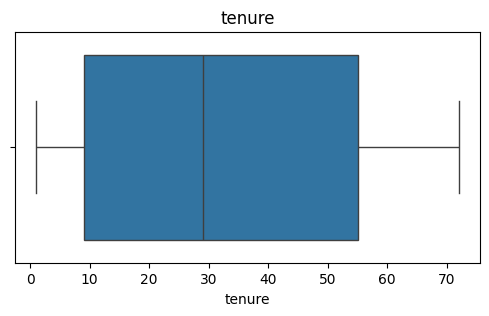

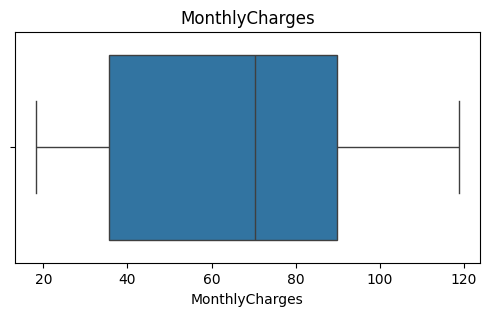

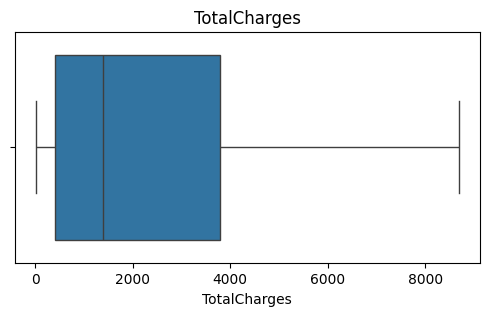

In [54]:
import matplotlib.pyplot as plt

for col in numerical_features:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [55]:
Q1 = df["MonthlyCharges"].quantile(0.25)
Q3 = df["MonthlyCharges"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["MonthlyCharges"] < lower) |
    (df["MonthlyCharges"] > upper)
]

print(len(outliers))

0


In [56]:
Q1 = df["TotalCharges"].quantile(0.25)
Q3 = df["TotalCharges"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["TotalCharges"] < lower) |
    (df["TotalCharges"] > upper)
]

print(len(outliers))

0


In [57]:
Q1 = df["tenure"].quantile(0.25)
Q3 = df["tenure"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["tenure"] < lower) |
    (df["tenure"] > upper)
]

print(len(outliers))

0


##### Relationship : tenure vs Churn

<Axes: xlabel='Churn', ylabel='tenure'>

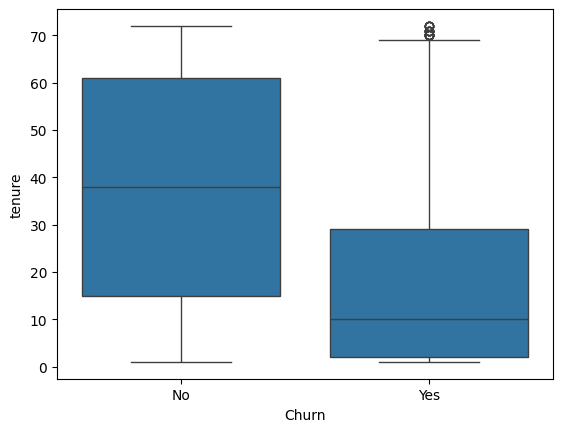

In [58]:
sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

- Customers who did not churn ("No") have a much higher median tenure.
Median ≈ 38 months.
- Customers who churned ("Yes") have a much lower median tenure.
Median ≈ 10 months.
- This suggests:
Customers with shorter tenure are more likely to churn.

In [59]:
##### Relationship : TotalCharges vs Churn

<Axes: xlabel='Churn', ylabel='TotalCharges'>

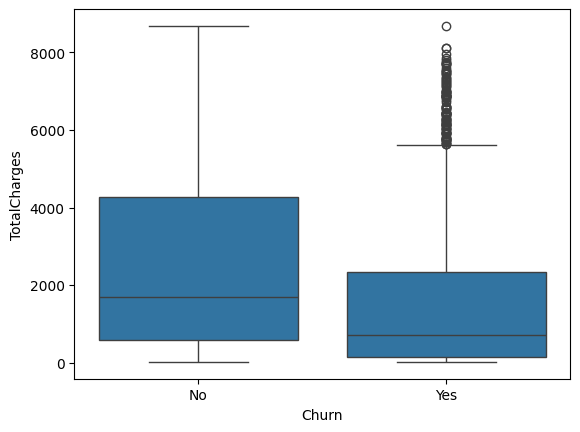

In [60]:
sns.boxplot(
    x="Churn",
    y="TotalCharges",
    data=df
)

- The median TotalCharges for customers who did not churn is much higher than for customers who churned.
- Approximate medians:
- Churn = No   → ~1700
- Churn = Yes  → ~700
- This suggests:
- Customers with higher accumulated charges tend to stay longer and are less likely to churn.

In [62]:
##### Relationship : MonthlyCharges vs Churn

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

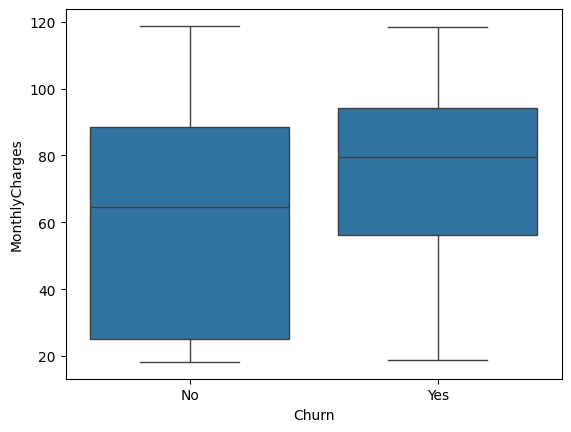

In [63]:
sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

- The median MonthlyCharge for customers  who churned is much higher than for customers who did not churn
- Approximate medians:
- Churn = No   → ~63
- Churn = Yes  → ~80
- This suggests:
- Customers with lower MonthlyCharge tend to stay longer and are less likely to churn.

<Axes: xlabel='Contract', ylabel='count'>

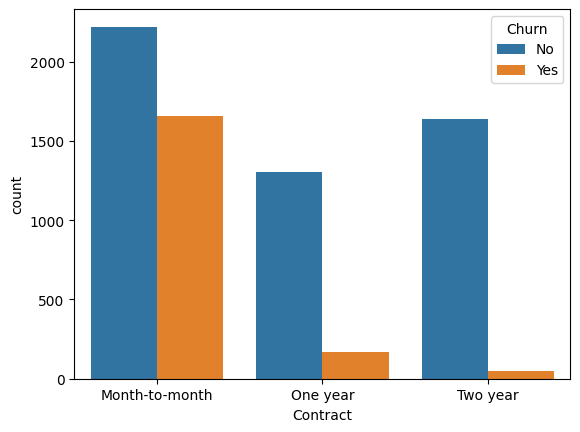

In [64]:
sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

- It seems that customer with contract  greater or equaltwo year tend to stay longer.

<Axes: xlabel='PaymentMethod', ylabel='count'>

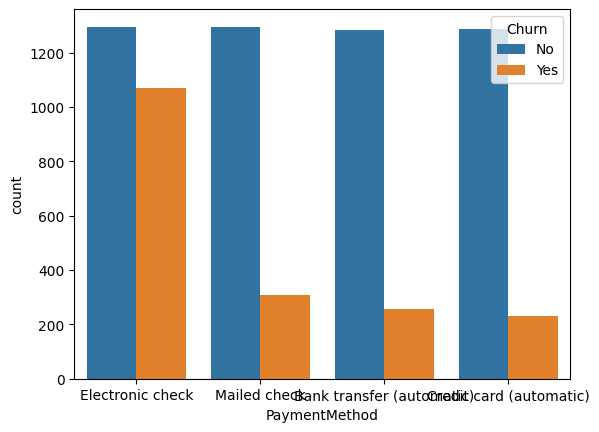

In [65]:
sns.countplot(
    x="PaymentMethod",
    hue="Churn",
    data=df
)

<Axes: xlabel='InternetService', ylabel='count'>

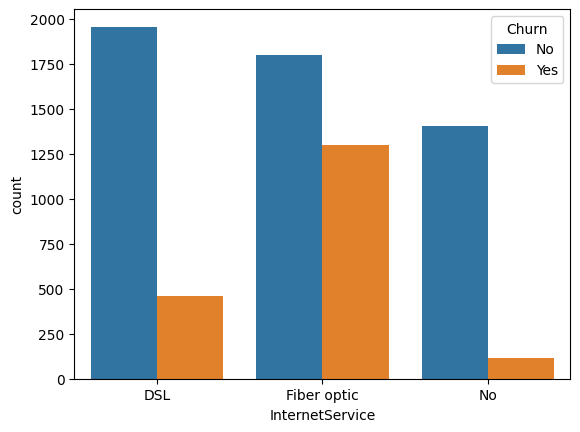

In [66]:
sns.countplot(
    x="InternetService",
    hue="Churn",
    data=df
)

<Axes: >

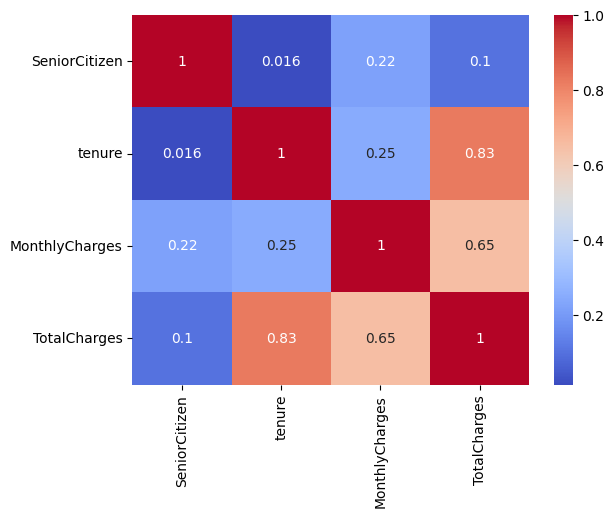

In [67]:
corr = df[numerical_features].corr()
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

- conclusion :
 1. The dataset contains 7043 customers.
 2. TotalCharges contained 11 missing values (0.16%).
 3. The target is moderately imbalanced:
   - No churn: 73.4%
   - Churn: 26.6%
 4. Customers with lower tenure are more likely to churn.
 5. Customers with lower TotalCharges are more likely to churn.